# Breast Tumor Classification — Exploratory Data Analysis

## Project Objective

The objective of this project is to analyze the Wisconsin Diagnostic Breast Cancer (WDBC) dataset and develop a machine learning workflow for classifying observations as benign or malignant.

This notebook focuses on:
- Loading and understanding the dataset
- Validating data quality
- Exploring the target variable
- Performing exploratory data analysis
- Understanding relationships between diagnostic features
- Identifying important patterns and observations for subsequent modeling

# Import Required Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

%matplotlib inline

# Load the Dataset

In [6]:
data_path = "wdbc.data"

df = pd.read_csv(data_path, header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


##  Assigning Column Names

In [8]:
columns = [
    "id",
    "diagnosis",
    
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

df.columns = columns

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3.2 Checking Dataset Dimensions


In [10]:
df.shape

(569, 32)

## Checking Column Names

In [12]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

##  Checking Data Types and Non-Null Values

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [16]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

# Checking Duplicates

In [18]:
df.duplicated().sum()

0

# Checking Unique Values

In [37]:
df["id"].nunique()


569

##  Target Variable Analysis

In [40]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

## Target Class Distribution

The target variable contains two classes: Benign (B) and Malignant (M).

In this section, we calculate the number and percentage of observations belonging to each class. This helps us understand the class balance of the dataset before developing the classification model.

In [43]:
class_counts = df["diagnosis"].value_counts()
class_percentages = df["diagnosis"].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

class_summary

,Count,Percentage
diagnosis,,
B,357,62.74
M,212,37.26


### Visualization of Target Class Distribution

The following bar chart visualizes the number of benign and malignant observations in the dataset.

This provides a quick visual understanding of the target class distribution and helps identify whether there is any noticeable class imbalance.

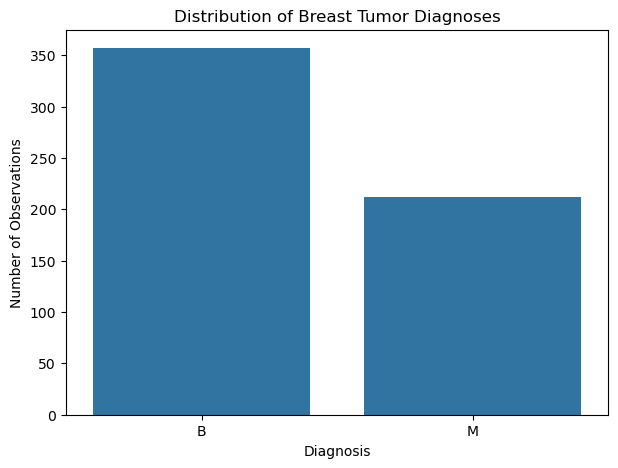

In [48]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="diagnosis",
    order=["B", "M"]
)

plt.title("Distribution of Breast Tumor Diagnoses")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Observations")

plt.show()

### Observation

The dataset contains 357 benign observations (62.74%) and 212 malignant observations (37.26%). Therefore, benign cases form the majority class, while malignant cases represent a smaller proportion of the dataset.

The class distribution shows some imbalance, which will be considered during model development and evaluation. In particular, recall for the malignant class will be monitored carefully because the project emphasizes correctly identifying malignant observations.

# Descriptive Statistics

Descriptive statistics provide a numerical summary of the diagnostic features in the dataset.

We will examine measures such as:
- Count
- Mean
- Standard deviation
- Minimum
- 25th percentile
- Median
- 75th percentile
- Maximum

This helps us understand the central tendency, variability, and range of the diagnostic measurements before performing further analysis.


In [53]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### Descriptive Statistics of Diagnostic Features

The `id` column is an identifier and does not represent a diagnostic characteristic. Therefore, it is excluded from the descriptive statistics below.

The following summary focuses only on the 30 diagnostic features used for analysis.

In [56]:
feature_columns = [col for col in df.columns if col not in ["id", "diagnosis"]]

df[feature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## Distribution of Mean Features

The dataset contains 10 primary measurements, each represented by a mean, standard error (SE), and worst value.

In this section, we visualize the distributions of the 10 mean features to understand their spread, shape, and potential skewness.

Histograms are used because they show how frequently different ranges of values occur within each feature.

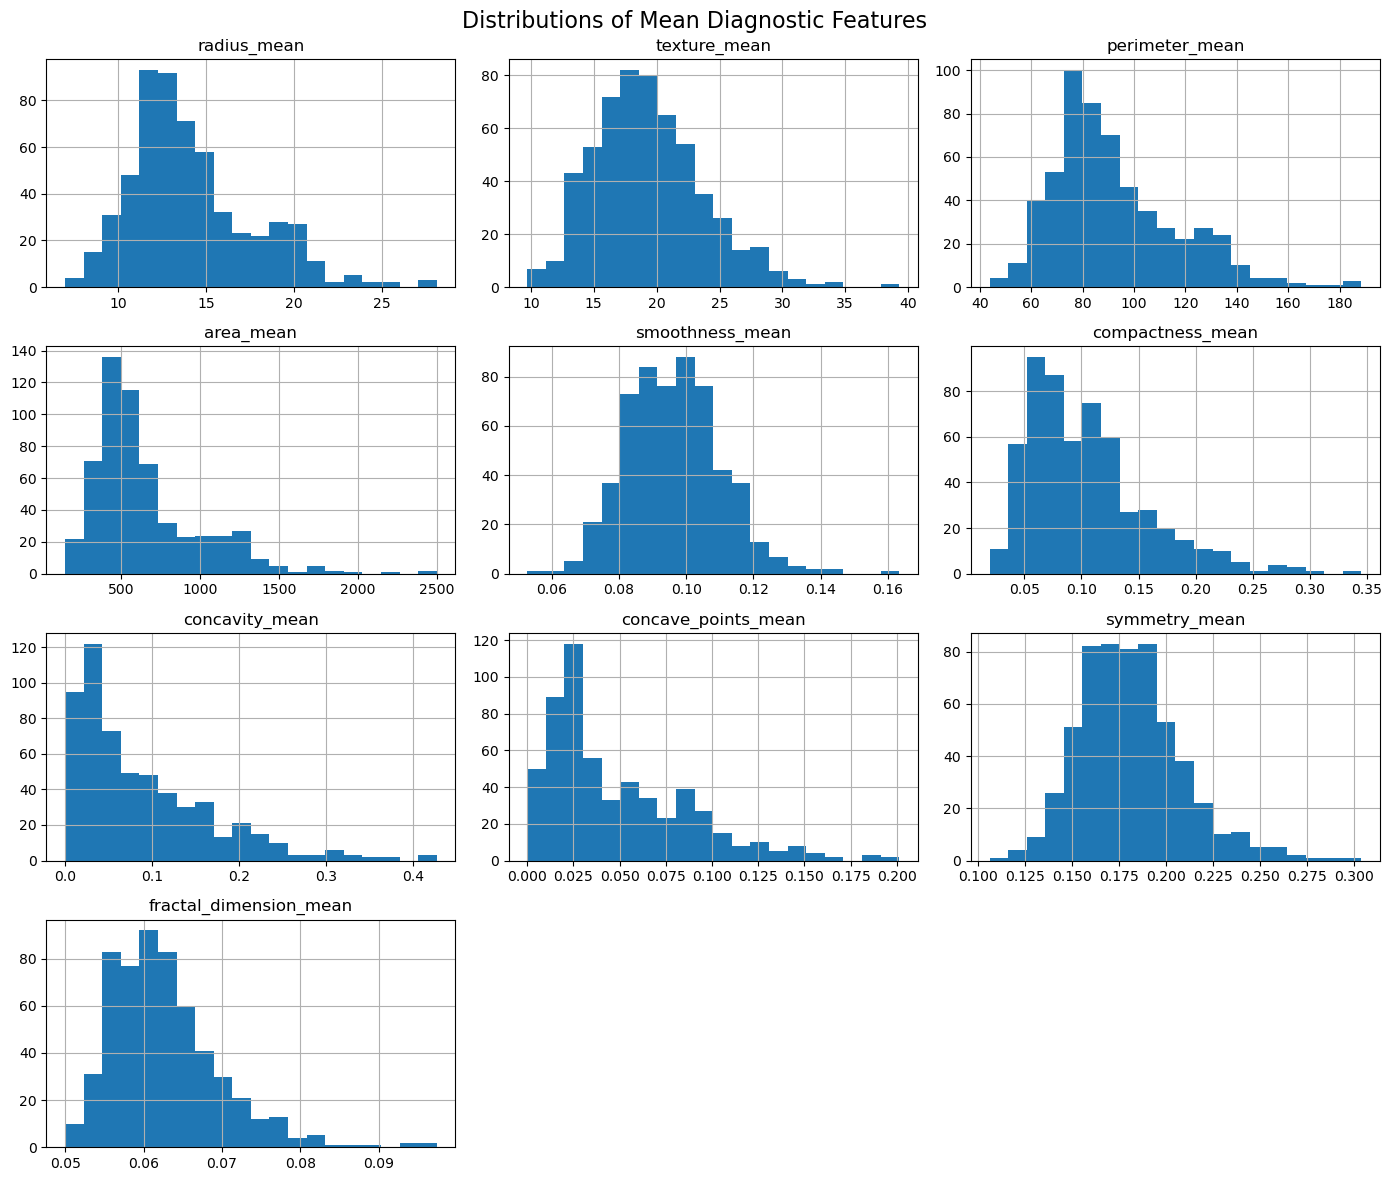

In [60]:
mean_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean"
]

df[mean_features].hist(
    figsize=(14, 12),
    bins=20
)

plt.suptitle("Distributions of Mean Diagnostic Features", fontsize=16)
plt.tight_layout()
plt.show()

### Observations from Feature Distributions

The distributions of the mean diagnostic features show different levels of spread and skewness. Several measurements, including radius, perimeter, area, compactness, concavity, and concave points, show right-skewed distributions with longer upper tails.

The features also operate on different numerical scales. These differences in scale will be important when applying distance-based clustering methods later in the project.

The presence of extreme values in some features will be investigated further using boxplots. Extreme observations will not automatically be treated as errors unless there is evidence that they are invalid.

##  Comparing Features Across Diagnosis Classes

To understand which diagnostic measurements may be useful for classification, we compare the distributions of selected mean features between benign and malignant observations.

Boxplots are used because they allow us to compare:
- The median of each group
- The spread of the observations
- Differences between benign and malignant groups
- Potential extreme observations

The comparison is exploratory and does not by itself establish a clinical conclusion.

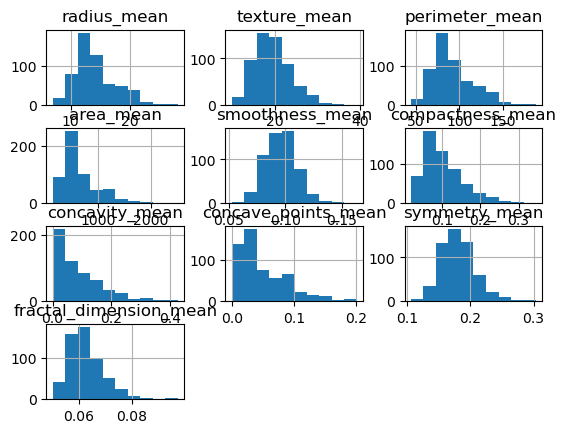

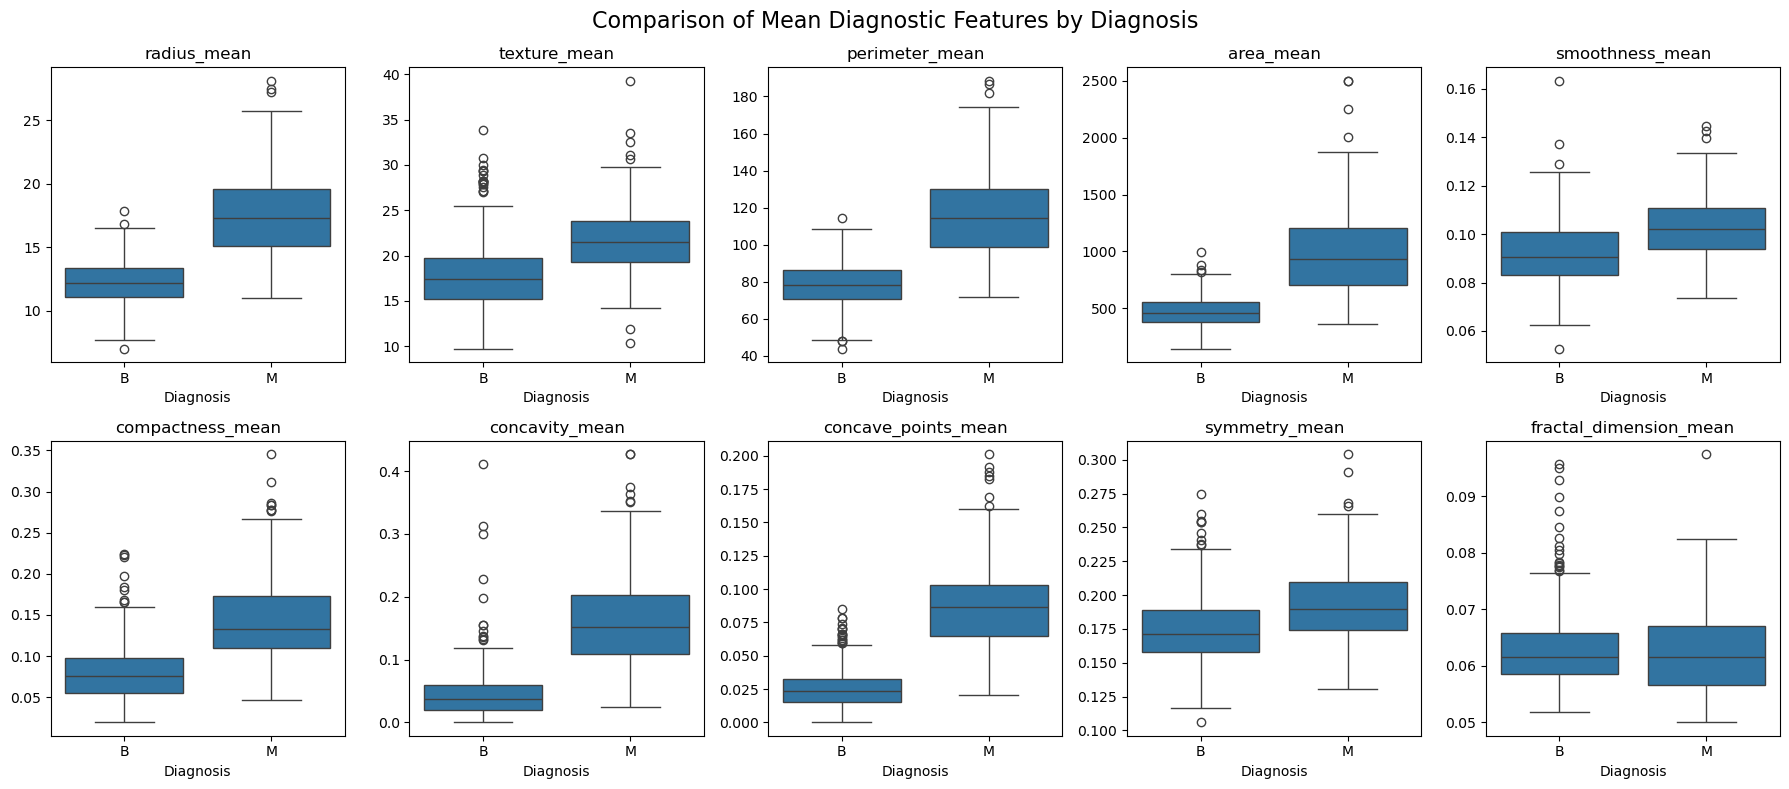

In [67]:
comparison_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean"
]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for ax, feature in zip(axes.flat, comparison_features):
    sns.boxplot(
        data=df,
        x="diagnosis",
        y=feature,
        order=["B", "M"],
        ax=ax
    )
    ax.set_title(feature)
    ax.set_xlabel("Diagnosis")
    ax.set_ylabel("")

plt.suptitle(
    "Comparison of Mean Diagnostic Features by Diagnosis",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Comparing Mean Feature Values by Diagnosis

The boxplots provide a visual comparison of the diagnostic features between benign and malignant observations.

To support these visual observations with numerical evidence, we calculate the average value of each selected mean feature separately for the two diagnosis classes.

This allows us to identify features where the average measurements differ between the groups.

In [70]:
class_feature_means = df.groupby("diagnosis")[comparison_features].mean().T

class_feature_means

diagnosis,B,M
radius_mean,12.146524,17.462830
texture_mean,17.914762,21.604906
perimeter_mean,78.075406,115.365377
area_mean,462.790196,978.376415
smoothness_mean,0.092478,0.102898
compactness_mean,0.080085,0.145188
concavity_mean,0.046058,0.160775
concave_points_mean,0.025717,0.087990
symmetry_mean,0.174186,0.192909
fractal_dimension_mean,0.062867,0.062680


### Observations

The numerical comparison supports several patterns observed in the boxplots. Features such as `radius_mean`, `perimeter_mean`, `area_mean`, `compactness_mean`, `concavity_mean`, and `concave_points_mean` show noticeable differences in their average values between benign and malignant observations.

In contrast, `fractal_dimension_mean` has very similar average values across the two classes, indicating greater overlap based on this measure alone.

These observations are exploratory and do not determine feature importance by themselves. The machine learning model will consider the combined information from all diagnostic features.

## Correlation Analysis

Correlation analysis is used to measure the strength and direction of linear relationships between the diagnostic features.

A correlation coefficient ranges from -1 to +1:

- **+1** indicates a strong positive relationship.
- **0** indicates little or no linear relationship.
- **-1** indicates a strong negative relationship.

Understanding correlations helps identify groups of features that contain similar information and provides insight into the structure of the dataset.

In [74]:
correlation_matrix = df[feature_columns].corr()

correlation_matrix.round(2)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.00,0.32,1.00,0.99,0.17,0.51,0.68,0.82,0.15,-0.31,...,0.97,0.30,0.97,0.94,0.12,0.41,0.53,0.74,0.16,0.01
texture_mean,0.32,1.00,0.33,0.32,-0.02,0.24,0.30,0.29,0.07,-0.08,...,0.35,0.91,0.36,0.34,0.08,0.28,0.30,0.30,0.11,0.12
perimeter_mean,1.00,0.33,1.00,0.99,0.21,0.56,0.72,0.85,0.18,-0.26,...,0.97,0.30,0.97,0.94,0.15,0.46,0.56,0.77,0.19,0.05
area_mean,0.99,0.32,0.99,1.00,0.18,0.50,0.69,0.82,0.15,-0.28,...,0.96,0.29,0.96,0.96,0.12,0.39,0.51,0.72,0.14,0.00
smoothness_mean,0.17,-0.02,0.21,0.18,1.00,0.66,0.52,0.55,0.56,0.58,...,0.21,0.04,0.24,0.21,0.81,0.47,0.43,0.50,0.39,0.50
compactness_mean,0.51,0.24,0.56,0.50,0.66,1.00,0.88,0.83,0.60,0.57,...,0.54,0.25,0.59,0.51,0.57,0.87,0.82,0.82,0.51,0.69
concavity_mean,0.68,0.30,0.72,0.69,0.52,0.88,1.00,0.92,0.50,0.34,...,0.69,0.30,0.73,0.68,0.45,0.75,0.88,0.86,0.41,0.51
concave_points_mean,0.82,0.29,0.85,0.82,0.55,0.83,0.92,1.00,0.46,0.17,...,0.83,0.29,0.86,0.81,0.45,0.67,0.75,0.91,0.38,0.37
symmetry_mean,0.15,0.07,0.18,0.15,0.56,0.60,0.50,0.46,1.00,0.48,...,0.19,0.09,0.22,0.18,0.43,0.47,0.43,0.43,0.70,0.44
fractal_dimension_mean,-0.31,-0.08,-0.26,-0.28,0.58,0.57,0.34,0.17,0.48,1.00,...,-0.25,-0.05,-0.21,-0.23,0.50,0.46,0.35,0.18,0.33,0.77


## Correlation Heatmap

A correlation heatmap provides a visual representation of the relationships between the 30 diagnostic features.

Strong positive correlations are represented by values close to +1, while strong negative correlations are represented by values close to -1.

The heatmap helps identify groups of highly correlated features and provides an overview of the relationships within the dataset.

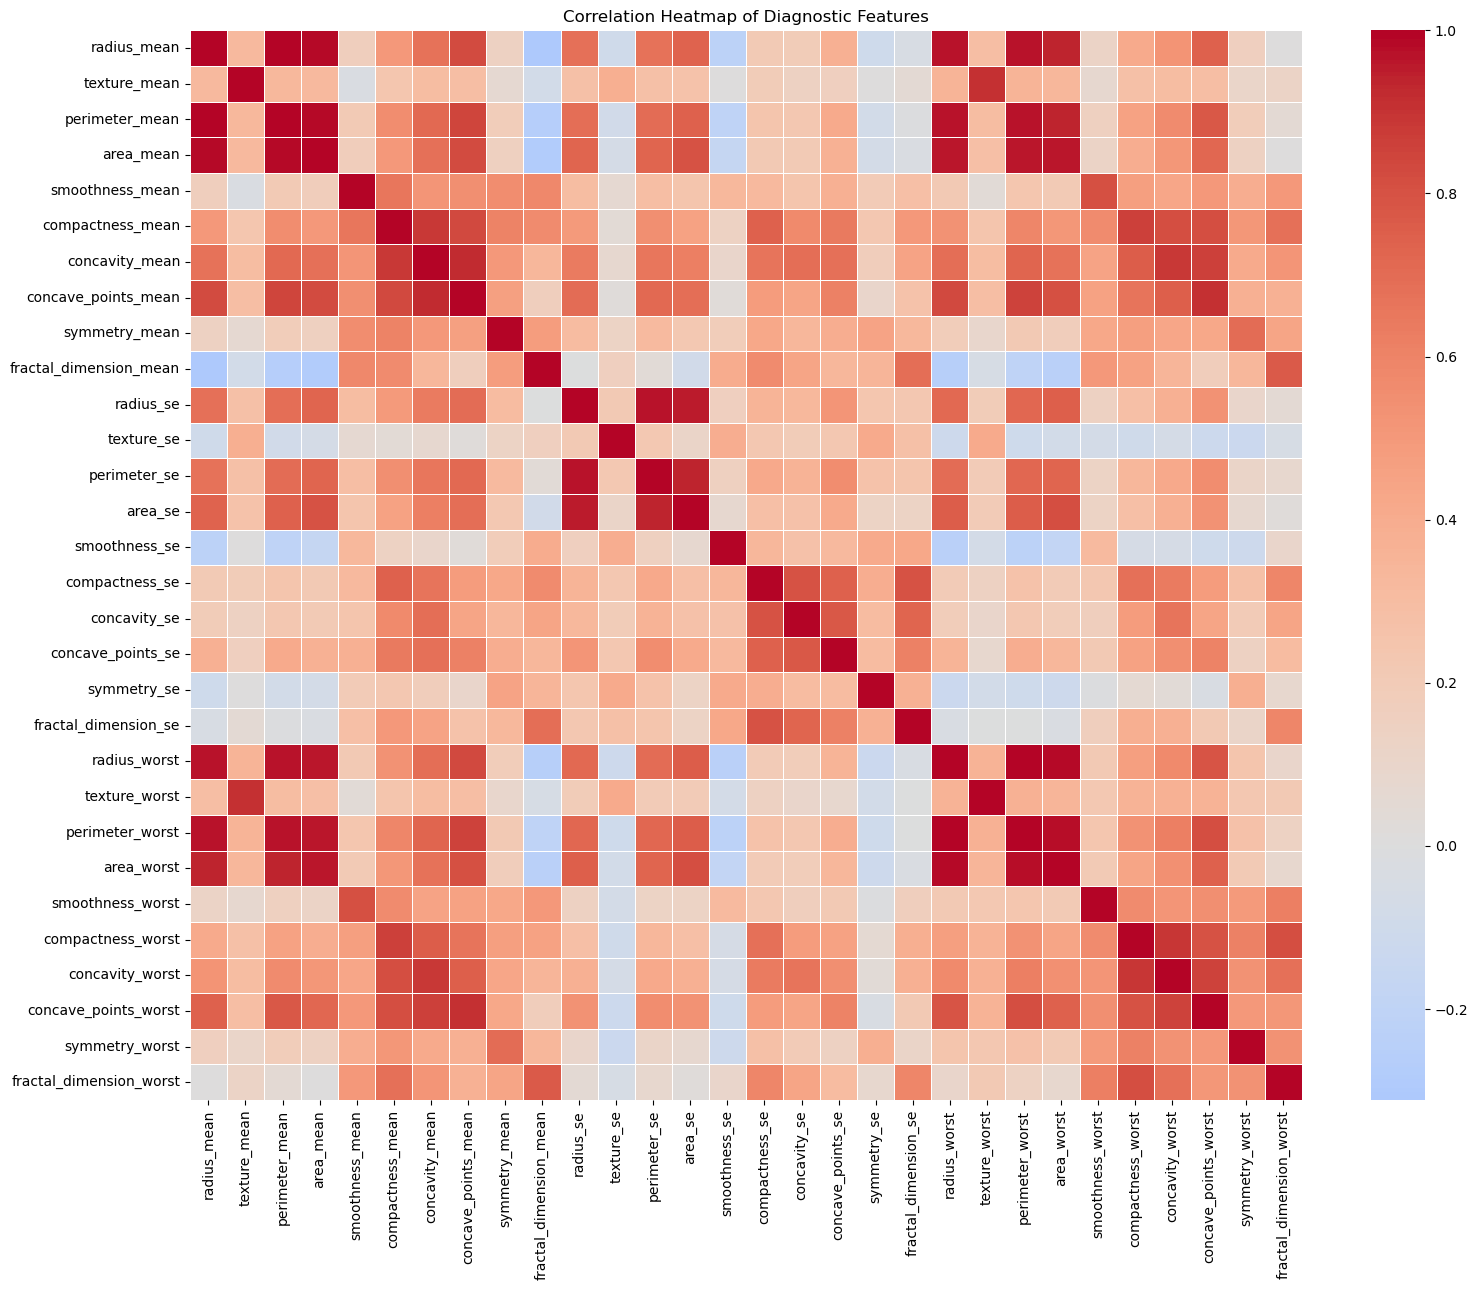

In [77]:
plt.figure(figsize=(16, 13))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Diagnostic Features")
plt.tight_layout()
plt.show()

### Observations

The correlation heatmap shows several groups of highly correlated diagnostic features. In particular, the mean measurements of radius, perimeter, and area exhibit very strong positive relationships. Similarly, compactness, concavity, and concave points show strong positive correlations.

These relationships indicate that some features contain overlapping information. This is important for understanding the structure of the dataset and may also affect feature selection and dimensionality considerations during modeling.

Correlation alone does not determine which features should be removed. Feature selection will be considered separately based on the requirements and performance of the machine learning models.

## Outlier Analysis

Outlier analysis is performed to identify observations that are unusually distant from the central range of a feature.

The Interquartile Range (IQR) method is used to identify potential outliers:

- IQR = Q3 − Q1
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Observations outside these bounds are considered potential outliers.

These observations will be investigated rather than automatically removed, because extreme measurements may represent genuine observations rather than data-entry errors.

In [84]:
Q1 = df[feature_columns].quantile(0.25)
Q3 = df[feature_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    (df[feature_columns] < lower_bound) |
    (df[feature_columns] > upper_bound)
).sum()

outlier_summary = (
    pd.DataFrame({"Outlier_Count": outlier_counts})
    .sort_values("Outlier_Count", ascending=False)
)

outlier_summary

,Outlier_Count
area_se,65
radius_se,38
perimeter_se,38
area_worst,35
smoothness_se,30
compactness_se,28
fractal_dimension_se,28
symmetry_se,27
area_mean,25
fractal_dimension_worst,24


### Outlier Analysis Findings

The IQR method identified potential outliers across several diagnostic features. `area_se` has the highest number of potential outliers, followed by `radius_se`, `perimeter_se`, and `area_worst`.

These observations are considered statistical outliers based on the IQR rule, but they are not automatically treated as erroneous data. Since the dataset contains genuine diagnostic measurements, extreme values may represent legitimate observations.

Therefore, no observations are removed solely on the basis of the IQR outlier analysis. The models will be evaluated using the available observations.

##  Standardized Feature Boxplots

The diagnostic features have substantially different numerical scales. To compare their distributions visually, the features are standardized before creating the boxplots.

Standardization is used here only to make the distributions comparable on a common scale. The original feature values are not modified.

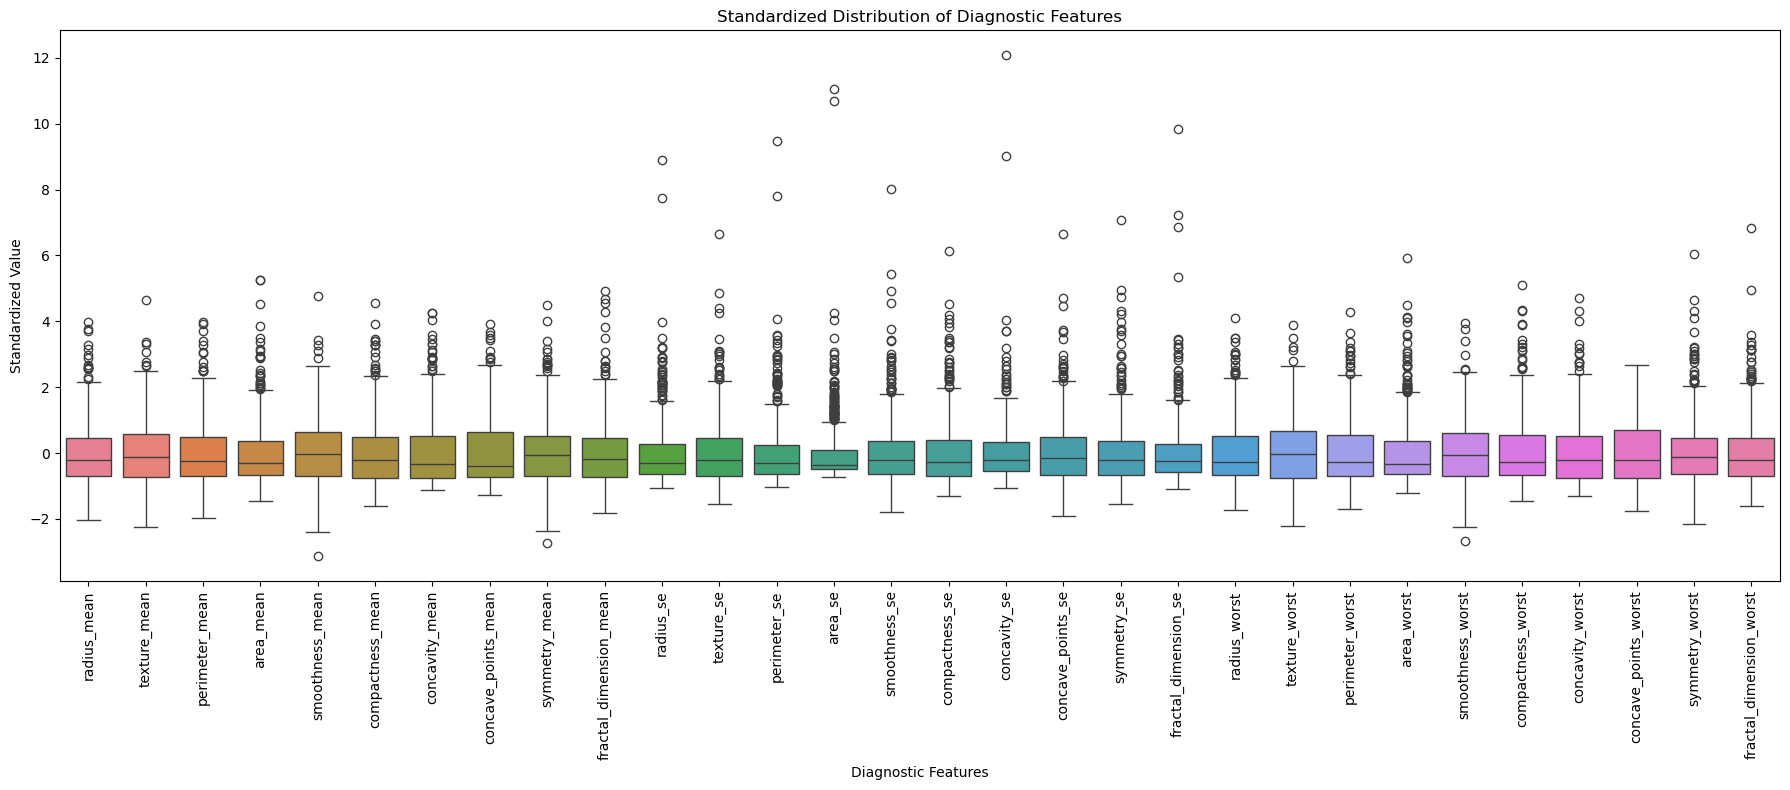

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(df[feature_columns])

scaled_df = pd.DataFrame(
    scaled_features,
    columns=feature_columns
)

plt.figure(figsize=(18, 8))

sns.boxplot(data=scaled_df)

plt.title("Standardized Distribution of Diagnostic Features")
plt.xlabel("Diagnostic Features")
plt.ylabel("Standardized Value")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Observations

The standardized boxplot confirms the presence of extreme observations across several diagnostic features. The number and extent of these observations vary between features.

These extreme values are consistent with the earlier IQR-based outlier analysis. Since there is no evidence that these observations are data-entry errors, they are retained in the dataset rather than being removed.

Standardization in this visualization was used only to make features with different numerical scales comparable. The original dataset remains unchanged.

# EDA Summary

The exploratory data analysis was performed to understand the structure, quality, distributions, relationships, and class differences within the breast cancer dataset.

The main findings from the EDA are summarized below.

In [92]:
eda_summary = pd.DataFrame({
    "Analysis": [
        "Dataset Size",
        "Missing Values",
        "Duplicate Records",
        "Benign Cases",
        "Malignant Cases",
        "Potential Outliers"
    ],
    "Finding": [
        f"{df.shape[0]} observations and {df.shape[1]} columns",
        "No missing values",
        f"{df.duplicated().sum()} duplicate records",
        f"{(df['diagnosis'] == 'B').sum()} (62.74%)",
        f"{(df['diagnosis'] == 'M').sum()} (37.26%)",
        "Present in several diagnostic features"
    ]
})

eda_summary

,Analysis,Finding
0,Dataset Size,569 observations and 32 columns
1,Missing Values,No missing values
2,Duplicate Records,0 duplicate records
3,Benign Cases,357 (62.74%)
4,Malignant Cases,212 (37.26%)
5,Potential Outliers,Present in several diagnostic features


### Overall EDA Conclusion

The dataset contains 569 observations and 32 columns, including an identifier, a binary diagnosis variable, and 30 numerical diagnostic features. No missing values or duplicate records were detected.

The target variable contains 357 benign and 212 malignant observations. Several diagnostic measurements show noticeable differences between the two diagnosis groups, while many features are also strongly correlated with one another.

Potential outliers are present in multiple features; however, they have been retained because they may represent legitimate observations rather than errors.

The dataset is therefore suitable for further preprocessing and machine learning analysis.